In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE, RFECV
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score, auc
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import numpy as np
import seaborn as sns

In [2]:
file_names = ['D:/FH/Masterstudiengang/Master/2.Semester/Struktur Vorhersagen/StrVoh/benchmark_data/B_10.out', 
              'D:/FH/Masterstudiengang/Master/2.Semester/Struktur Vorhersagen/StrVoh/benchmark_data/B_20.out', 
              'D:/FH/Masterstudiengang/Master/2.Semester/Struktur Vorhersagen/StrVoh/benchmark_data/B_30.out', 
              'D:/FH/Masterstudiengang/Master/2.Semester/Struktur Vorhersagen/StrVoh/benchmark_data/C_10.out', 
              'D:/FH/Masterstudiengang/Master/2.Semester/Struktur Vorhersagen/StrVoh/benchmark_data/C_20.out', 
              'D:/FH/Masterstudiengang/Master/2.Semester/Struktur Vorhersagen/StrVoh/benchmark_data/C_30.out']

data = []  # Liste für die Daten jeder Datei

for file_name in file_names:
    file_data = []  # Liste für die Daten der aktuellen Datei
    with open(file_name, 'r') as file:
        for line in file:
            columns = line.strip().split('\t')
            last_column = columns[-1]
            file_data.append(last_column)  # Daten der aktuellen Zeile zur Liste hinzufügen
    data.append(file_data)  # Daten der Datei zur übergeordneten Liste hinzufügen

df = pd.DataFrame(data)  # DataFrame erstellen
df = df.transpose()
df.columns = ["B_10", "B_20", "B_30", "C_10", "C_20", "C_30"]
print(df)

        B_10    B_20    B_30   C_10   C_20  C_30
0      -5.34  -22.24  -11.55  -1.17   0.56  0.61
1      -8.14  -11.07  -18.12  -2.51  -2.45  0.45
2      -5.96  -16.92   -6.53   0.21   0.70  0.62
3      -5.34   -9.84  -10.61   0.26   0.56  0.53
4      -4.09   -8.14   -7.55   0.48  -0.32  0.44
...      ...     ...     ...    ...    ...   ...
1755  -13.88  -22.38  -28.24   0.21   0.22  0.10
1756  -10.47  -14.13  -23.84   0.43   0.24  0.11
1757  -15.88  -23.80  -19.38   0.30  -6.08  0.14
1758   -8.74  -18.45  -16.02   0.19   0.20  0.10
1759  -18.48  -14.12  -16.40   0.44   0.28  0.00

[1760 rows x 6 columns]


In [3]:
B_10 = df["B_10"].astype(float).describe().to_frame()
B_20 = df["B_20"].astype(float).describe().to_frame()
B_30 = df["B_30"].astype(float).describe().to_frame()
C_10 = df["C_10"].astype(float).describe().to_frame()
C_20 = df["C_20"].astype(float).describe().to_frame()
C_30 = df["C_30"].astype(float).describe().to_frame()

summary = pd.concat([B_10, B_20, B_30, C_10, C_20, C_30], axis=1)
summary.columns = ["B_10", "B_20", "B_30", "C_10", "C_20", "C_30"]

print(summary)


              B_10         B_20          B_30         C_10         C_20  \
count  1760.000000  1760.000000   1760.000000  1760.000000  1760.000000   
mean    -35.031381   -82.459824   -221.541852    -0.647466    -0.957182   
std     106.374654   304.540165   2337.362728     1.884913     7.134769   
min   -2681.330000 -7163.840000 -90224.600000   -20.970000  -221.570000   
25%     -30.112500   -56.850000    -80.920000    -1.072500    -0.310000   
50%     -17.700000   -26.055000    -33.260000     0.160000     0.150000   
75%     -11.070000   -15.305000    -18.147500     0.350000     0.260000   
max       0.550000     0.450000      0.220000     1.520000     1.320000   

              C_30  
count  1760.000000  
mean     -1.418545  
std      15.521856  
min    -571.710000  
25%       0.000000  
50%       0.110000  
75%       0.212500  
max       1.230000  


In [10]:
X_train, X_test, y_train, y_test = train_test_split(df[["B_10"]], df[["C_10"]], test_size=0.3, random_state=0)
print("X_train: " + str(X_train.shape))
print("y_train: " + str(y_train.shape))
print("X_test: " + str(X_test.shape))
print("y_test: " + str(y_test.shape))

# Reshape der Eingabevariablen
X_train = X_train.values.reshape(-1, 1)
X_test = X_test.values.reshape(-1, 1)

# Logistische Regression durchführen
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Vorhersagen auf dem Testdatensatz machen
y_pred = model.predict(X_test)


X_train: (1232, 1)
y_train: (1232, 1)
X_test: (528, 1)
y_test: (528, 1)


c:\Users\Stefan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Stefan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# ROC-AUC Funktion

In [11]:
def receiverOperationCharacteristics(x, y, z):
    # Beispiel-Daten
    positive_file = x.astype(float)  # Positive Control Set
    negative_file = y.astype(float)  # Negative Control Set

    # Labels für positive und negative Daten erstellen
    positive_labels = np.ones(len(positive_file))
    negative_labels = np.zeros(len(negative_file))

    # Daten und Labels zusammenführen
    data = pd.concat([positive_file, negative_file], axis=0)
    labels = np.concatenate([positive_labels, negative_labels])

    # ROC-Kurve berechnen
    fpr, tpr, thresholds = roc_curve(labels, data)

    # AUC berechnen
    auc_score = auc(fpr, tpr)

    # ROC-Kurve plotten
    plt.plot(fpr, tpr, label='ROC curve (AUC = %0.2f)' % auc_score)
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(z)
    plt.legend(loc="upper left")
    plt.show()

# ROC-Plots

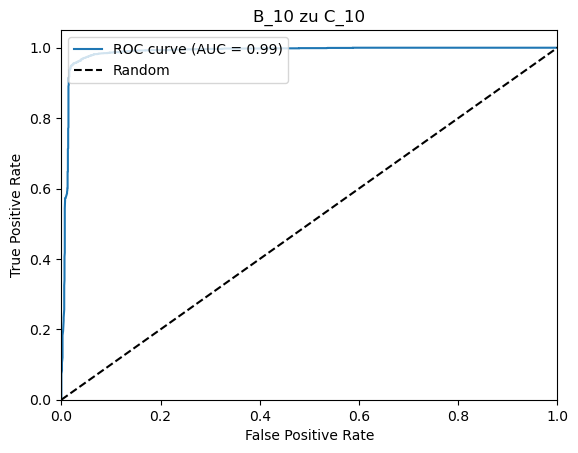

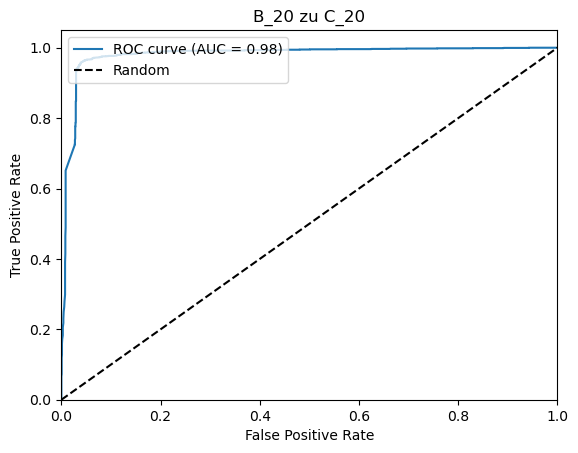

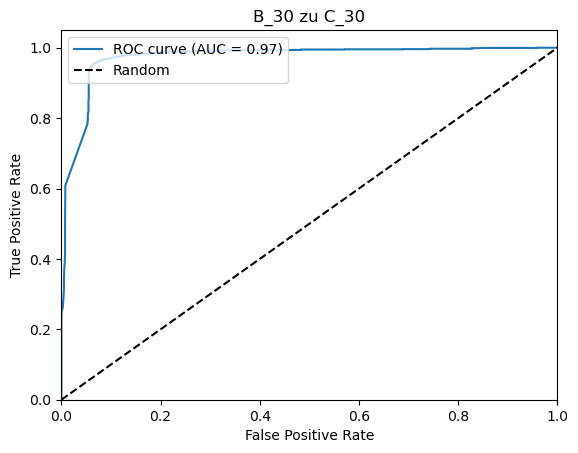

In [15]:
column_names = ["B_10", "B_20", "B_30"]
for column in column_names:
    positive_file = df[column]
    negative_file = df["C" + column[1:]]  # entsprechende Spalte für negatives Control Set
    title = f"{column} zu C{column[1:]}"
    receiverOperationCharacteristics(negative_file, positive_file, title)


# Histogramm


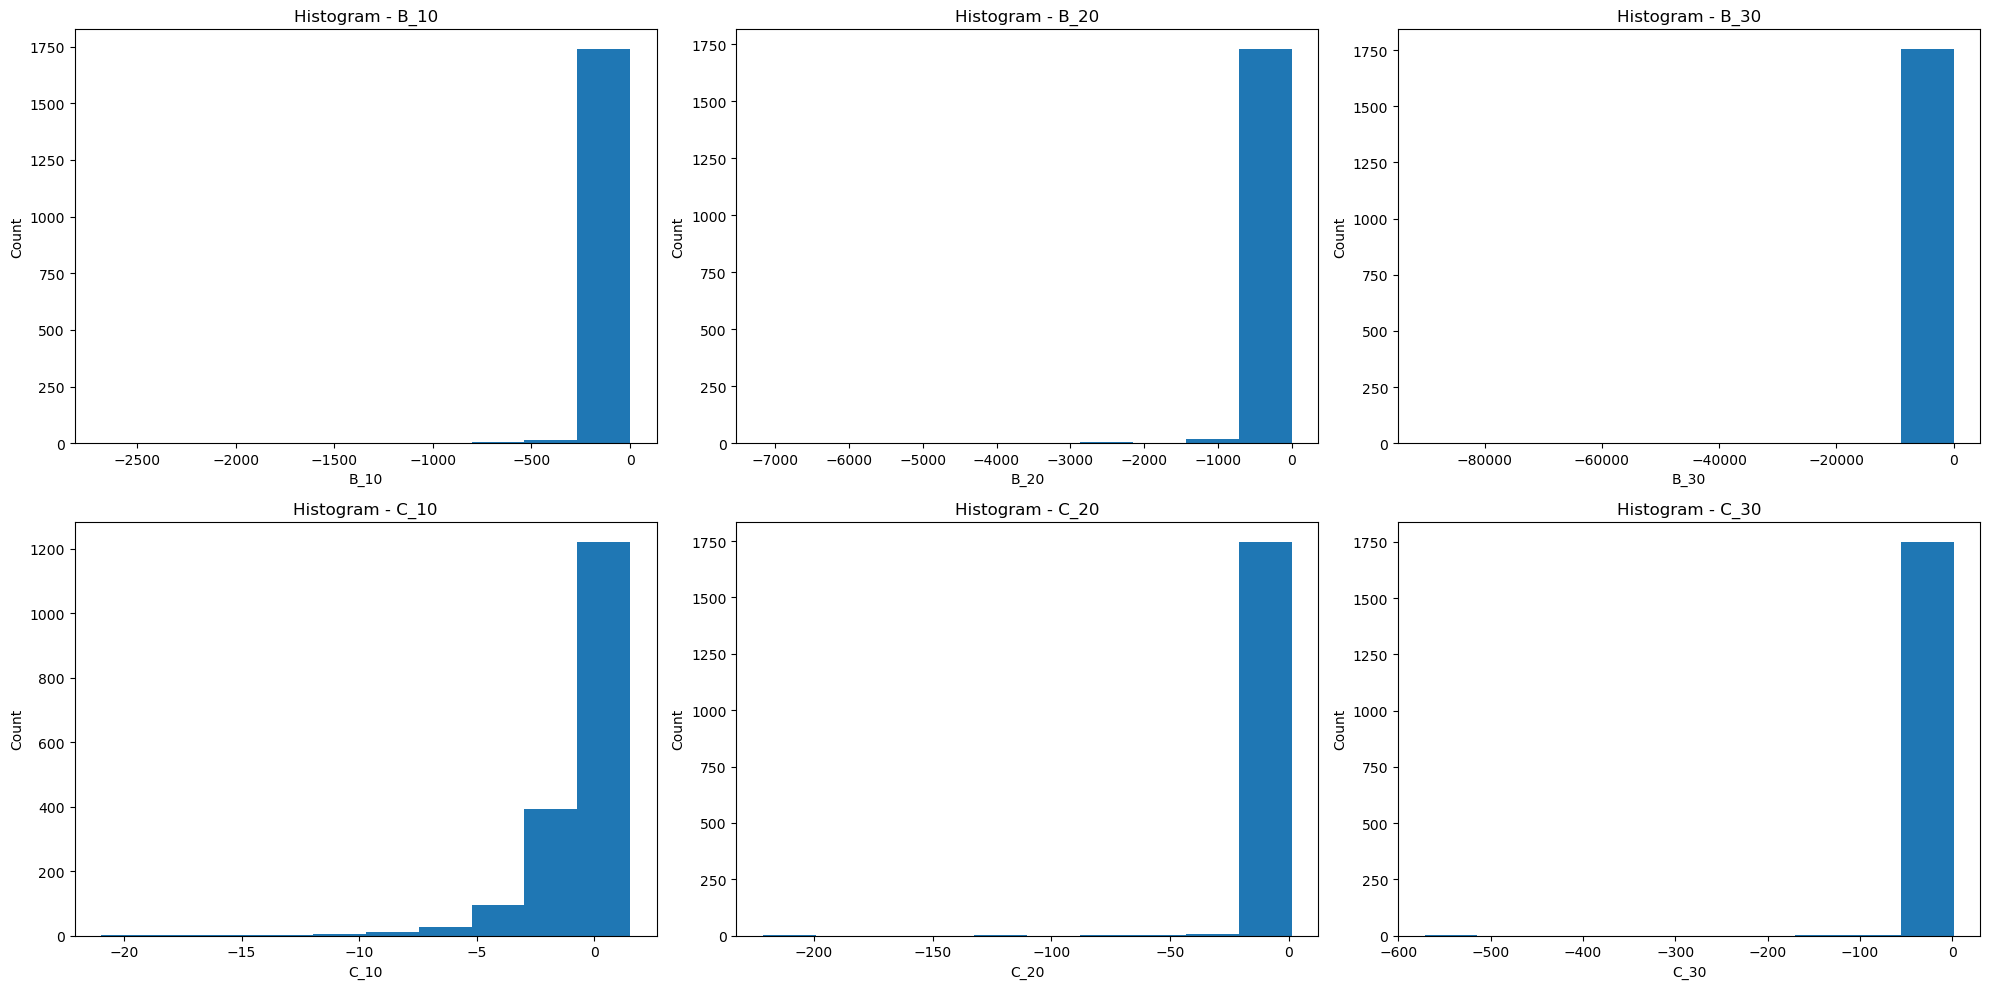

In [13]:
fig, ax = plt.subplots(2, 3, figsize=(20, 10))

# Histogramm für B_10
ax[0, 0].hist(df["B_10"].astype(float))
ax[0, 0].set_xlabel("B_10")
ax[0, 0].set_ylabel("Count")
ax[0, 0].set_title("Histogram - B_10")

# Histogramm für B_20
ax[0, 1].hist(df["B_20"].astype(float))
ax[0, 1].set_xlabel("B_20")
ax[0, 1].set_ylabel("Count")
ax[0, 1].set_title("Histogram - B_20")

# Histogramm für B_30
ax[0, 2].hist(df["B_30"].astype(float))
ax[0, 2].set_xlabel("B_30")
ax[0, 2].set_ylabel("Count")
ax[0, 2].set_title("Histogram - B_30")

# Histogramm für C_10
ax[1, 0].hist(df["C_10"].astype(float))
ax[1, 0].set_xlabel("C_10")
ax[1, 0].set_ylabel("Count")
ax[1, 0].set_title("Histogram - C_10")

# Histogramm für C_20
ax[1, 1].hist(df["C_20"].astype(float))
ax[1, 1].set_xlabel("C_20")
ax[1, 1].set_ylabel("Count")
ax[1, 1].set_title("Histogram - C_20")

# Histogramm für C_30
ax[1, 2].hist(df["C_30"].astype(float))
ax[1, 2].set_xlabel("C_30")
ax[1, 2].set_ylabel("Count")
ax[1, 2].set_title("Histogram - C_30")

plt.tight_layout()
plt.show()


c:\Users\Stefan\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Stefan\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Stefan\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Stefan\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Stefan\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Stefan\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountere

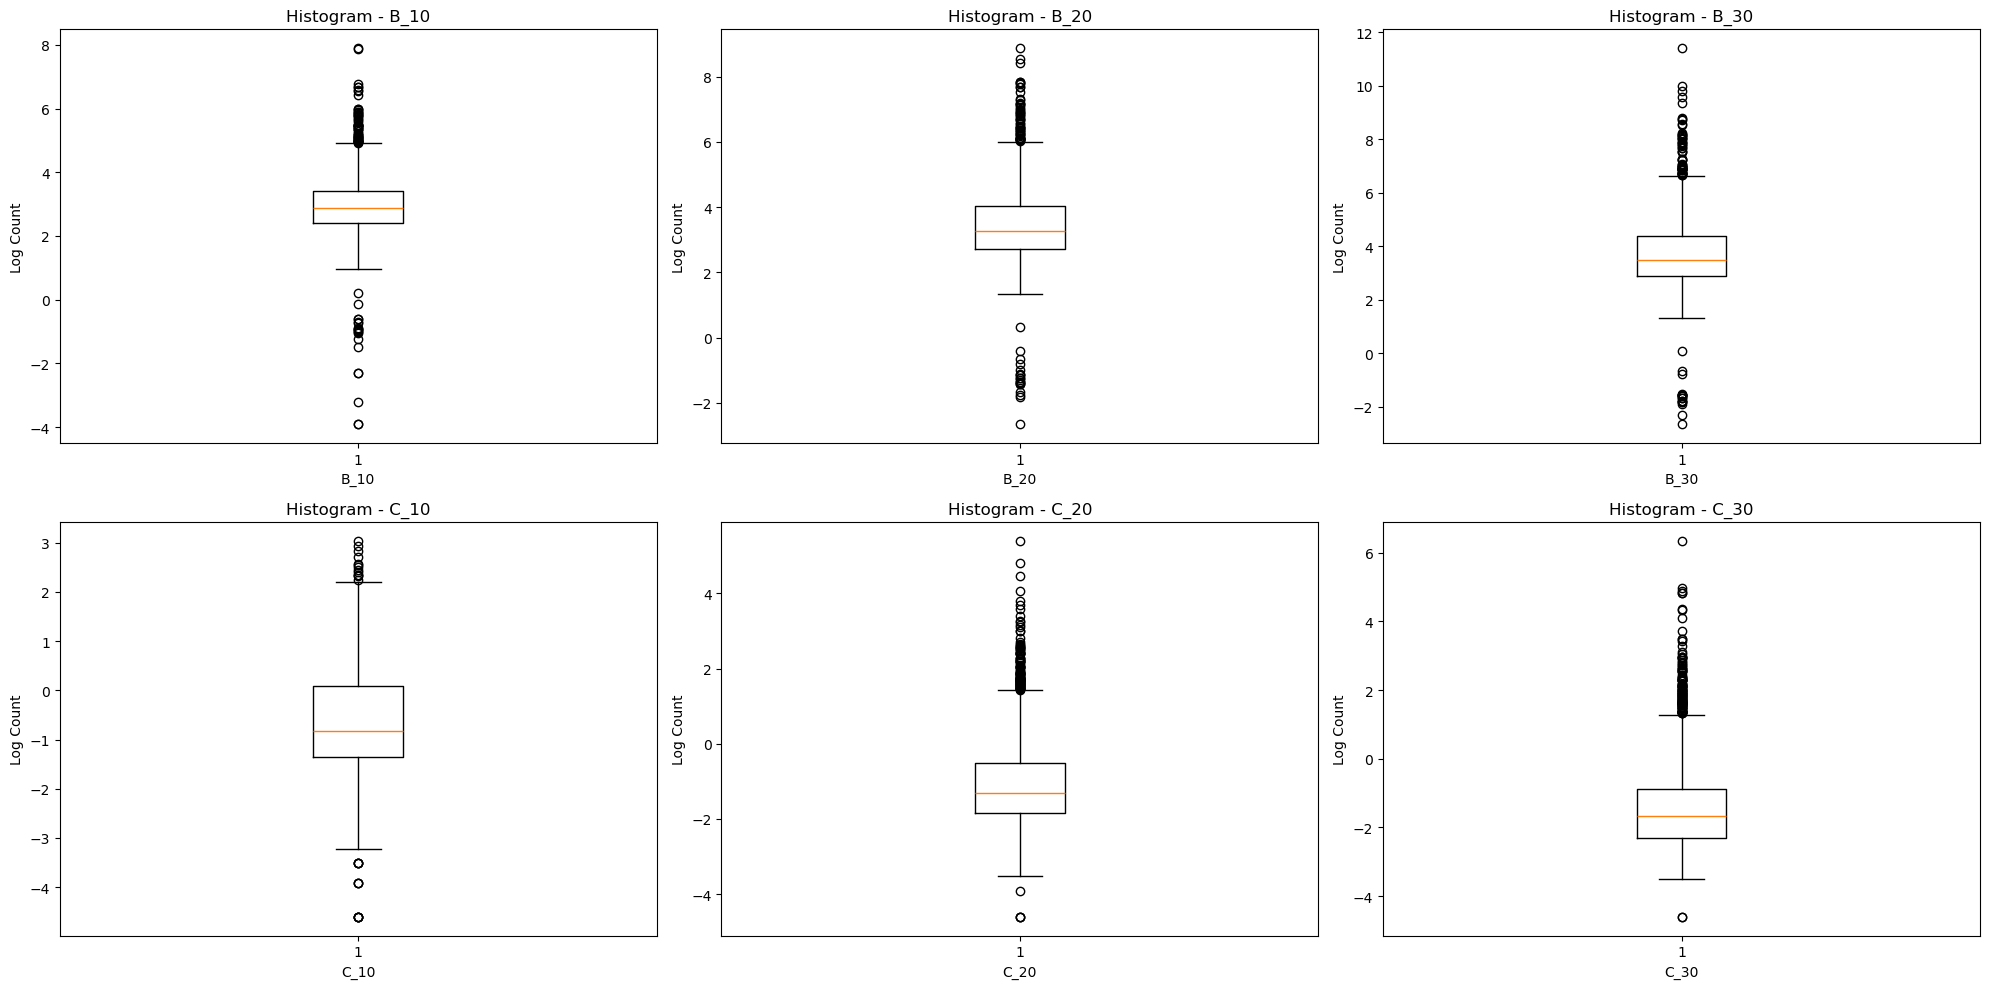

In [14]:
fig, ax = plt.subplots(2, 3, figsize=(20, 10))

# Histogramm für B_10
ax[0, 0].boxplot(np.log(np.abs(df["B_10"].astype(float))))
ax[0, 0].set_xlabel("B_10")
ax[0, 0].set_ylabel("Log Count")
ax[0, 0].set_title("Histogram - B_10")

# Histogramm für B_20
ax[0, 1].boxplot(np.log(np.abs(df["B_20"].astype(float))))
ax[0, 1].set_xlabel("B_20")
ax[0, 1].set_ylabel("Log Count")
ax[0, 1].set_title("Histogram - B_20")

# Histogramm für B_30
ax[0, 2].boxplot(np.log(np.abs(df["B_30"].astype(float))))
ax[0, 2].set_xlabel("B_30")
ax[0, 2].set_ylabel("Log Count")
ax[0, 2].set_title("Histogram - B_30")

# Histogramm für C_10
ax[1, 0].boxplot(np.log(np.abs(df["C_10"].astype(float))))
ax[1, 0].set_xlabel("C_10")
ax[1, 0].set_ylabel("Log Count")
ax[1, 0].set_title("Histogram - C_10")

# Histogramm für C_20
ax[1, 1].boxplot(np.log(np.abs(df["C_20"].astype(float))))
ax[1, 1].set_xlabel("C_20")
ax[1, 1].set_ylabel("Log Count")
ax[1, 1].set_title("Histogram - C_20")

# Histogramm für C_30
ax[1, 2].boxplot(np.log(np.abs(df["C_30"].astype(float))))
ax[1, 2].set_xlabel("C_30")
ax[1, 2].set_ylabel("Log Count")
ax[1, 2].set_title("Histogram - C_30")

plt.tight_layout()
plt.show()
